# 3.6 Logistic regression

_Warning!_ Although it is called logistic _regression_, logistic regression is actually a _classification_ method.

By Ariane Ducellier (2021)

In this lab, we are going to talk about:
- A simple classification method: Logistic regression
- Gradient descent method
- Automatic differentiation
- Introduction to PyTorch

## Logistic regression

Remember linear regression:

$y = b + x w + \epsilon$

$y$ is a vector of length $n$, $x$ is a matrix with $n$ rows and $p$ columns, corresponding to $n$ observations and $p$ features that are used to explain $y$.

$b$ is a scalar. $w$ is a vector of length $p$. $\epsilon$ is a random error vector, of length $n$. It is independent of $x$, and has mean of zero.

Our objective is to find the best values of $b$ and $w$ so that the values of $\hat{y} = b + x w$ are as close as possible to the actual values $y$.

For linear regression, $y$ is a quantitative variable. What if $y$ is a qualitative variable, for example $y = 0$ for "no", and $y = 1$ for "yes"?

One way to use regression to solve a classification problem is to model the probability of the variable $y$ taking the value 1:

$P (y = 1) = b + x w$

Once we have found the best values $\hat{b}$ and $\hat{w}$, we compute $\hat{y} = \hat{b} + x \hat{w}$. If $\hat{y} \geq 0.5$, we decide to classify this observation as $y = 1$, that is "yes". If $\hat{y} < 0.5$, we decide to classify this observation as $y = 0$, that is "no".

There is a problem with this method. We would like to have $0 \leq P (y = 1) \leq 1$ because it is a probability. However, there is nothing in this formulation that forces $b$ and $w$ to take values such that $\hat{y} = \hat{b} + x \hat{w}$ will always take values in $[0, 1]$.

To solve this problem, we can instead write:

$z = b + x w$ and $P (y = 1) = \frac{1}{1 + e^{-z}}$

That way, we always have $0 \leq P (y = 1) \leq 1$. When $b + x w$ gets large, $P (y = 1)$ gets close to 1, and the value "yes" is more and more likely. When $b + x w$ gets small, $P (y = 1)$ gets close to 0, and the value "no" is more and more likely.

How do we find the optimal value of $b$ and $w$? We define the cross-entropy loss function. For one observation, the loss function is:

$\mathcal{L} = - (y_i \log \hat{y}_i + (1 - y_i) \log (1 - \hat{y}_i)$ with $\hat{y}_i = \frac{1}{1 + e^{- (b + x_i^T w)}}$ where $x_i$ is the $i$th row of x.

If the true observation $y_i$ is 1 ("yes") and $\hat{y}_i = 1$, the loss function takes the value 0. If $\hat{y}_i = 0$, the loss function tends to infinity.

If the true observation $y$ is 0 ("no") and $\hat{y}_i = 0$, the loss function takes the value 0. If $\hat{y}_i = 1$, the loss function tends to infinity.

For all the $n$ observations, we write:

$\mathcal{L} = \sum_{i = 1}^n \mathcal{L}_i$

Our objective is thus to find the values of $b$ and $\omega$ that minimize the loss function. Note that with this formulation, $\mathcal{L}$ is always positive.

## Gradient descent

We know that the gradient $\frac{\partial \mathcal{L}}{\partial w_j}$ is positive if the loss $\mathcal{L}$ increases when $w_j$ increases. Reversely, the gradient $\frac{\partial \mathcal{L}}{\partial w_j}$ is negative if the loss $\mathcal{L}$ decreases when $w_j$ increases.

To obtain smaller and smaller values of the loss, at each iteration we take:

$w_j^{(k + 1)} = w_j^{(k)} - \alpha \frac{\partial \mathcal{L}}{\partial w_j}$ for $j = 1 , \cdots , p$

$b^{(k + 1)} = b^{(k)} - \alpha \frac{\partial \mathcal{L}}{\partial b}$

We assume that the value of $\alpha$ is not too big. If the gradient is positive, then the value of $w_j$ will decrease at each iteration, and the value of the loss function will decrease. If the gradient is negative, then the value of $w_j$ will increase at each iteration, and the value of the loss will decrease.

So now, all we need to do is to compute the gradient of the loss function. 

## Automatic differentiation

There are three ways of computing the gradient. The first method is to use the formula of the loss:

$\mathcal{L} (w_j , b) = - \sum_{i = 1}^n y_i \log (\frac{1}{1 + \exp (- b - \sum_{j = 1}^p w_j x_{i,j})}) + (1 - y_i) \log (1 - \frac{1}{1 + \exp (- b - \sum_{j = 1}^p w_j x_{i,j})})$

and to calculate the exact formula of the derivatives $\frac{\partial \mathcal{L}}{\partial w_j}$ and $\frac{\partial \mathcal{L}}{\partial b}$. You just then have to implement the exact formula in the code to compute the gradient.

When the formula gets more and more complicated, you become more and more likely to make a mistake, either in the calculation of the derivative formula, either in the implementation in your code.

The second method is to compute an approximation of the gradient:

$\frac{\partial \mathcal{L}}{\partial w_j} = \frac{\mathcal{L}(w_j + \Delta w_j) - \mathcal{L}(w_j)}{\Delta W_j}$

If you write too many approximations, the method may not work very well and give inexact results.

The third method is to use automatic differentiation. If we write:

$z = x_i^T w + b = f_x(w, b)$, $\sigma = \frac{1}{1 + e^{-z}} = g(z)$ and $L = - (y_i \log(\sigma) + (1 - y_i) \log(1 - \sigma)) = h_y(\sigma)$, we get:

$\frac{\partial L}{\partial w_j} = \frac{\partial f}{\partial w_j} g'(z) h'(\sigma)$

It is very easy to compute the exact formula of the derivatives:

$\frac{\partial f}{\partial w_j}(w, b) = x_{i,j}$

$g'(z) = \frac{e^{-z}}{(1 + e^{-z})^2}$

$h'(\sigma) = - \frac{y_i}{\sigma} + \frac{1 - y_i}{1 - \sigma}$

When computing $L$, we thus need to keep in memory the values of $\frac{\partial f}{\partial w_j}(w, b)$, $g'(z)$, and $h'(\sigma)$ to be able to compute the gradient. That is what PyTorch is doing.

## Introduction to PyTorch

PyTorch (https://pytorch.org/) is a Python package which allows you to build and train neural networks. It is based on automatic differentiation.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pooch
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

## The data: water potability

We use a table of water-quality measurements with a binary target, `Potability` (0 = not potable, 1 = potable). Each row has 9 numeric features (pH, hardness, dissolved solids, and so on).

```{admonition} Data provenance
:class: warning
This table circulated on Kaggle (https://www.kaggle.com/adityakadiwal/water-potability) with no documented source, and it is probably synthetic. We use it as a teaching table for binary classification, not as a real water-quality study. Do not draw any conclusions about actual drinking water from it.
```

In [2]:
path = pooch.retrieve(
    url="https://raw.githubusercontent.com/UW-MLGEO/MLGeo-dataset/main/data/water_potability.csv",
    known_hash=None,
    fname="water_potability.csv",
    path=pooch.os_cache("mlgeo"),
)
data = pd.read_csv(path)

Some rows have missing values. We drop them and reset the row index.

In [3]:
data = data.dropna()
data = data.reset_index(drop=True)

In [4]:
data.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
1,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0
2,5.584087,188.313324,28748.687739,7.544869,326.678363,280.467916,8.399735,54.917862,2.559708,0
3,10.223862,248.071735,28749.716544,7.513408,393.663396,283.651634,13.789695,84.603556,2.672989,0
4,8.635849,203.361523,13672.091764,4.563009,303.309771,474.607645,12.363817,62.798309,4.401425,0


In [5]:
x = data.drop(columns=['Potability']).to_numpy()
y = data.Potability.to_numpy()
print(x.shape, y.shape)

(2011, 9) (2011,)


## Split before you scale

We set aside 30% of the rows as a test set before doing anything else. We fit the scaler on the training rows only and apply it to both sets: if the scaler saw the test rows, information about the test set would leak into training, and the final evaluation would no longer be honest.

In [6]:
x_train, x_test, y_train_np, y_test_np = train_test_split(
    x, y, test_size=0.3, random_state=42, stratify=y)

scaler = StandardScaler().fit(x_train)
x_train = scaler.transform(x_train)
x_test = scaler.transform(x_test)
print(x_train.shape, x_test.shape)

(1407, 9) (604, 9)


Before training anything, compute the trivial baseline: a "model" that always predicts the most common class. Any classifier worth keeping must beat this number.

In [7]:
baseline = max(np.mean(y_train_np == 0), np.mean(y_train_np == 1))
print(f"Majority-class baseline accuracy: {baseline:.3f}")

Majority-class baseline accuracy: 0.597


## One observation, by hand

We are going to compute the loss corresponding to the first observation in the training set. Instead of using Numpy arrays to put our data and parameters, we are going to use torch tensors, because they have properties that Numpy arrays do not have.

This is the features of the first training observation:

In [8]:
x_i = torch.from_numpy(x_train[0, :])
x_i = x_i.float()
x_i

tensor([-0.0951,  0.0145,  2.0111,  0.8662, -0.3787,  0.7364,  0.1168, -1.5465,
         0.6595])

This is the class of the first training observation:

In [9]:
y_i = float(y_train_np[0])
print(y_i)

1.0


Let us take random values for $w$ and $b$. When creating these variables, we use the option `requires_grad=True` because we will later want to compute the gradient with respect to these variables.

In [10]:
W = torch.rand(9, requires_grad=True)
B = torch.rand(1, requires_grad=True)

Let us define $z = f(w, b) = x_i^T w + b$. We have $\frac{\partial f}{\partial w_j} = x_{i,j}$ and $\frac{\partial f}{\partial b} = 1$.

By default, PyTorch only keeps gradients for leaf tensors like `W` and `B`. Intermediate tensors such as $z$ do not keep their gradients; calling `retain_grad()` asks PyTorch to store them so we can inspect them after the backward pass.

In [11]:
z = W.dot(x_i) + B
z.retain_grad()
z

tensor([2.0350], grad_fn=<AddBackward0>)

Let us define $\sigma = g(z) = \frac{1}{1 + e^{-z}} = g(f(w, b)) = (g \circ f) (w, b)$. We have $g'(z) = \frac{e^{-z}}{(1 + e^{-z})^2}$.

In [12]:
sigma = 1.0 / (1.0 + torch.exp(- z))
sigma.retain_grad()
sigma

tensor([0.8844], grad_fn=<MulBackward0>)

Note that here we use the function torch.exp instead of numpy.exp. That is because numpy just calculate the value of $e^x$ but does not know that the derivative of $e^x$ is $e^x$. If we want to be able to use automatic differentiation, we need to use the equivalent torch function that will compute both $\sigma(z)$ and $\frac{\partial \sigma}{\partial z}(z)$. This last value will be necessary and we will later compute the gradient.

Let us define $L = h(\sigma) = - (y_i \log(\sigma) + (1 - y_i) \log(1 - \sigma)) = h(g(z)) = h(g(f(w, b))) = (h \circ g \circ f) (w, b)$. We have $L'(\sigma) = - (\frac{y_i}{\sigma} - \frac{1 - y_i}{1 - \sigma})$.

In [13]:
L = - (y_i * torch.log(sigma) + (1 - y_i) * torch.log(1 - sigma))

We can now compute the gradient of the loss for one observation. This command computes the gradient of L with respect to all the variables that keep a gradient, that is W, B, z, and sigma, but it does not return the value.

In [14]:
L.backward()

We have $\frac{\partial L}{\partial \sigma} = - (\frac{y_i}{\sigma} - \frac{1 - y_i}{1 - \sigma})$. Let us compare the result from PyTorch with the exact mathematical formula.

In [15]:
h_prime = - (y_i / sigma - (1 - y_i) / (1 - sigma))
print(sigma.grad.item(), h_prime.item())

-1.1306867599487305 -1.1306867599487305


We have $\frac{\partial L}{\partial z} = g'(z) h'(g(z))$ that is $\frac{\partial L}{\partial z} = g'(z) h'(\sigma)$. Let us compare the result from PyTorch with the exact mathematical formula.

In [16]:
g_prime = torch.exp(- z) / ((1 + torch.exp(- z)) ** 2.0)
print(z.grad.item(), (g_prime * h_prime).item())

-0.11558175832033157 -0.11558175832033157


We have $\frac{\partial L}{\partial b} = \frac{\partial f}{\partial b} g'(f(w, b)) h'(g(f(w, b)))$ that is $\frac{\partial L}{\partial b} = \frac{\partial f}{\partial b} g'(z) h'(\sigma)$. Similarly, we have $\frac{\partial L}{\partial w_j} = \frac{\partial f}{\partial w_j} g'(f(w, b)) h'(g(f(w, b)))$ that is $\frac{\partial L}{\partial w_j} = \frac{\partial f}{\partial w_j} g'(z) h'(\sigma)$. Let us compare the results from PyTorch with the exact mathematical formulas.

In [17]:
print(B.grad.item(), (1 * g_prime * h_prime).item())

-0.11558175832033157 -0.11558175832033157


In [18]:
print(W.grad)
print((x_i * g_prime * h_prime).detach())

tensor([ 0.0110, -0.0017, -0.2324, -0.1001,  0.0438, -0.0851, -0.0135,  0.1787,
        -0.0762])
tensor([ 0.0110, -0.0017, -0.2324, -0.1001,  0.0438, -0.0851, -0.0135,  0.1787,
        -0.0762])


## Implementation of logistic regression

Let us now implement logistic regression using the whole training set.

In [19]:
X = torch.from_numpy(x_train).float()
Y = torch.from_numpy(y_train_np).float()

We could code the update rule $w^{(k+1)} = w^{(k)} - \alpha \, \partial \mathcal{L} / \partial w$ by hand, and earlier editions of this book did, with `retain_grad` bookkeeping at every step. `torch.optim.SGD` does exactly that update rule, so we let it handle the parameter updates and keep the loss formula explicit. We write the binary cross-entropy out in full rather than calling `torch.nn.BCELoss` — the point here is transparency, not convenience.

Two practical details:
- We clamp $\sigma$ away from 0 and 1 before taking logs, so the loss never returns `log(0)`.
- We stop when the relative change in the loss drops below $10^{-6}$, or after 2000 iterations.

In [20]:
p = X.size()[1]
W = torch.zeros(p, requires_grad=True)
B = torch.zeros(1, requires_grad=True)
optimizer = torch.optim.SGD([W, B], lr=0.1)

max_iter = 2000
losses = []
for i in range(max_iter):
    optimizer.zero_grad()
    z = X @ W + B
    sigma = torch.sigmoid(z)
    sigma = torch.clamp(sigma, 1e-7, 1 - 1e-7)
    L = - (Y * torch.log(sigma) + (1 - Y) * torch.log(1 - sigma)).mean()
    L.backward()
    optimizer.step()
    losses.append(L.item())
    if i > 0 and abs(losses[-1] - losses[-2]) / abs(losses[-2]) < 1e-6:
        break

print(f"Stopped after {len(losses)} iterations, final training loss: {losses[-1]:.4f}")

Stopped after 155 iterations, final training loss: 0.6707


Plot the loss curve. It should decrease quickly at first, then flatten.

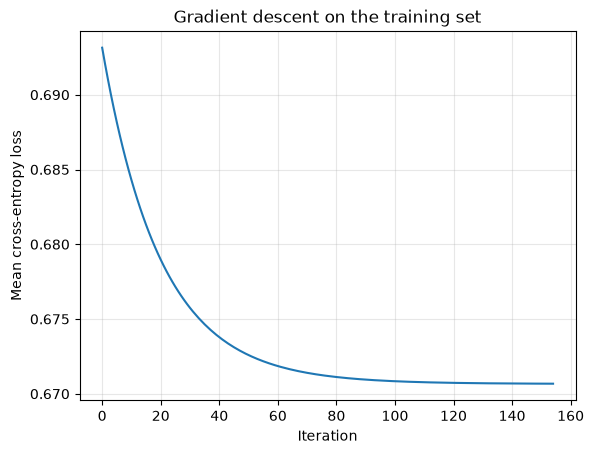

In [21]:
plt.plot(losses)
plt.xlabel('Iteration')
plt.ylabel('Mean cross-entropy loss')
plt.title('Gradient descent on the training set')
plt.grid(alpha=0.3)
plt.show()

## Evaluation on the test set

We now predict on both the training set and the test set. Earlier editions of this lesson evaluated the model on the same data it was trained on; the gap between the two numbers below is exactly why that overstates skill.

In [22]:
X_test_t = torch.from_numpy(x_test).float()
with torch.no_grad():
    proba_train = torch.sigmoid(X @ W + B).numpy()
    proba_test = torch.sigmoid(X_test_t @ W + B).numpy()

yhat_train = np.where(proba_train > 0.5, 1, 0)
yhat_test = np.where(proba_test > 0.5, 1, 0)

Let us now compute some classification metrics by hand, on the test set. `N_test` is the number of test observations.

In [23]:
y_test = y_test_np
N_test = len(y_test)

In [24]:
# True positive
tp = np.sum((y_test == 1) & (yhat_test == 1))
print(tp / N_test)

0.006622516556291391


In [25]:
# False negative
fn = np.sum((y_test == 1) & (yhat_test == 0))
print(fn / N_test)

0.3973509933774834


In [26]:
# False positive
fp = np.sum((y_test == 0) & (yhat_test == 1))
print(fp / N_test)

0.004966887417218543


In [27]:
# True negative
tn = np.sum((y_test == 0) & (yhat_test == 0))
print(tn / N_test)

0.5910596026490066


In [28]:
# Accuracy (percentage of correct classifications)
accuracy = (tp + tn) / (tp + tn + fp + fn)
print(accuracy)

0.597682119205298


In [29]:
# Recall (= sensitivity = percentage of positive values correctly classified)
recall = tp / (tp + fn)
print(recall)

0.01639344262295082


In [30]:
# Precision (= percentage of positive predictions that were correct)
precision = tp / (tp + fp)
print(precision)

0.5714285714285714


In [31]:
# F1
F1 = (2 * precision * recall) / (precision + recall)
print(F1)

0.03187250996015936


Now compare training accuracy against test accuracy, next to the majority-class baseline.

In [32]:
train_accuracy = np.mean(yhat_train == y_train_np)
test_accuracy = np.mean(yhat_test == y_test)
print(f"Baseline (majority class): {baseline:.3f}")
print(f"Train accuracy:            {train_accuracy:.3f}")
print(f"Test accuracy:             {test_accuracy:.3f}")

Baseline (majority class): 0.597
Train accuracy:            0.606
Test accuracy:             0.598


Logistic regression barely beats the majority-class baseline on this table, and the recall on the potable class is low. That is an honest result: these 9 features, combined linearly, carry little signal about the target. A near-null result reported against a baseline is more useful than an inflated training-set score. If someone reports only a training accuracy, ask what the baseline was and what a held-out set says.

## Appendix

Logistic regression is a nice example to start learning about automatic differentiation and PyTorch. However, if you actually want to use logistic regression for your own dataset, it is much easier to use the function already existing in scikit-learn. We follow the same protocol: fit on the training set, report on the test set.

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_recall_fscore_support

In [34]:
model = LogisticRegression(random_state=0).fit(x_train, y_train_np)

In [35]:
model.coef_

array([[ 0.04513734, -0.02944814,  0.12027801,  0.05730839, -0.04010493,
        -0.07808411,  0.02579578,  0.00593486,  0.02137578]])

In [36]:
model.intercept_

array([-0.39579648])

In [37]:
yhat_sk = model.predict(x_test)

In [38]:
metrics = precision_recall_fscore_support(y_test, yhat_sk, average='binary')
(precision_sk, recall_sk, F1_sk) = (metrics[0], metrics[1], metrics[2])
print(precision_sk, recall_sk, F1_sk)

0.5714285714285714 0.01639344262295082 0.03187250996015936


In [39]:
print(f"sklearn train accuracy: {model.score(x_train, y_train_np):.3f}")
print(f"sklearn test accuracy:  {model.score(x_test, y_test):.3f}")

sklearn train accuracy: 0.606
sklearn test accuracy:  0.598
